LeanDojo Demo
=============

This notebook demonstrates the main features of LeanDojo (using Lean 4). Please refer to the [documentation](https://leandojo.readthedocs.io/en/latest/) for more details.

In [ ]:
# Cell 1: Set up environment with verbose logging
import os
import sys

# Set GitHub access token (optional, for higher API rate limits)
# Get your token from: https://github.com/settings/tokens
# os.environ["GITHUB_ACCESS_TOKEN"] = "your_token_here"

# Enable verbose logging with loguru
from loguru import logger

# Remove default handler and add one with DEBUG level
logger.remove()  # Remove default handler
logger.add(
    sys.stderr,
    level="DEBUG",  # Show all debug messages
    format="<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | <cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> - <level>{message}</level>",
    colorize=True
)

# Alternative: simpler format showing just level and message
# logger.add(sys.stderr, level="DEBUG", format="{time:HH:mm:ss} | {level} | {message}")

print("Verbose logging enabled!")

# Cell 2: Import and trace (or load from cache if exists)
from pathlib import Path
from lean_dojo import *

repo = LeanGitRepo(
    "https://github.com/leanprover-community/mathlib4",
    "29dcec074de168ac2bf835a77ef68bbe069194c5",
)

# Check if traced repo already exists on disk
dst_dir = Path("traced_mathlib4")
traced_path = dst_dir / repo.name  # e.g., traced_mathlib4/mathlib4

if traced_path.exists() and (traced_path / ".git").exists():
    print(f"Loading existing traced repo from {traced_path}...")
    traced_repo = TracedRepo.load_from_disk(traced_path, build_deps=True)
    traced_repo.check_sanity()
    print(f"Loaded successfully!")
else:
    print(f"Tracing repo (this may take a while)...")
    traced_repo = trace(repo, dst_dir=dst_dir)

Verbose logging enabled!
Loading existing traced repo from traced_mathlib4\mathlib4...


2025-12-26 13:52:39,152	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
c:\Users\chowdhary\Desktop\lean-dojo\.venv\Lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
100%|██████████| 5674/5674 [06:07<00:00, 15.42it/s]  


Loaded successfully!


## Extract Data from Lean

In [2]:

print(f"Traced repo: {traced_repo}")
print(f"Number of ztraced files: {len(list(traced_repo.traced_files_graph.nodes()))}")

Traced repo: TracedRepo(repo=LeanGitRepo(url='C:\\Users\\chowdhary\\Desktop\\lean-dojo\\traced_mathlib4\\mathlib4', commit='29dcec074de168ac2bf835a77ef68bbe069194c5'), dependencies={'lean4': LeanGitRepo(url='https://github.com/leanprover/lean4', commit='3b58e0649156610ce3aeed4f7b5c652340c668d4'), 'batteries': LeanGitRepo(url='https://github.com/leanprover-community/batteries', commit='bba0af6e930ebcbabfacf021b21dd881d58aaa9d'), 'Qq': LeanGitRepo(url='https://github.com/leanprover-community/quote4', commit='a7bfa63f5dddbcab2d4e0569c4cac74b2585e2c6'), 'aesop': LeanGitRepo(url='https://github.com/leanprover-community/aesop', commit='a64fe24aa94e21404940e9217363a9a1ed9a33a6'), 'proofwidgets': LeanGitRepo(url='https://github.com/leanprover-community/ProofWidgets4', commit='d1b33202c3a29a079f292de65ea438648123b635'), 'Cli': LeanGitRepo(url='https://github.com/leanprover/lean4-cli', commit='a11566029bd9ec4f68a65394e8c3ff1af74c1a29'), 'importGraph': LeanGitRepo(url='https://github.com/leanprov

In [4]:
repo.get_config("lean-toolchain")

{'content': 'leanprover/lean4:v4.10.0-rc1\n'}

In [6]:
traced_repo.traced_files_graph

In [7]:
len(traced_repo.traced_files)

5674

In [8]:
traced_file = traced_repo.get_traced_file("Mathlib/Algebra/BigOperators/Pi.lean")

traced_file

TracedFile(root_dir=WindowsPath('C:/Users/chowdhary/Desktop/lean-dojo/traced_mathlib4/mathlib4'), repo=LeanGitRepo(url='C:\\Users\\chowdhary\\Desktop\\lean-dojo\\traced_mathlib4\\mathlib4', commit='29dcec074de168ac2bf835a77ef68bbe069194c5'), lean_file=LeanFile(path=WindowsPath('Mathlib/Algebra/BigOperators/Pi.lean')))

In [9]:
traced_file.get_premise_definitions()

[{'full_name': 'Pi.list_prod_apply',
  'code': '@[to_additive]\ntheorem list_prod_apply {α : Type*} {β : α → Type*} [∀ a, Monoid (β a)] (a : α)\n    (l : List (∀ a, β a)) : l.prod a = (l.map fun f : ∀ a, β a ↦ f a).prod',
  'start': [22, 1],
  'end': [25, 38],
  'kind': 'commanddeclaration'},
 {'full_name': 'Pi.multiset_prod_apply',
  'code': '@[to_additive]\ntheorem multiset_prod_apply {α : Type*} {β : α → Type*} [∀ a, CommMonoid (β a)] (a : α)\n    (s : Multiset (∀ a, β a)) : s.prod a = (s.map fun f : ∀ a, β a ↦ f a).prod',
  'start': [29, 1],
  'end': [32, 42],
  'kind': 'commanddeclaration'},
 {'full_name': 'Finset.prod_apply',
  'code': '@[to_additive (attr := simp)]\ntheorem Finset.prod_apply {α : Type*} {β : α → Type*} {γ} [∀ a, CommMonoid (β a)] (a : α)\n    (s : Finset γ) (g : γ → ∀ a, β a) : (∏ c ∈ s, g c) a = ∏ c ∈ s, g c a',
  'start': [38, 1],
  'end': [41, 38],
  'kind': 'commanddeclaration'},
 {'full_name': 'Finset.prod_fn',
  'code': '@[to_additive "An \'unapplied\' ana

In [10]:
traced_theorems = traced_file.get_traced_theorems()

len(traced_theorems)

13

In [11]:
thm = traced_file.get_traced_theorem("pi_eq_sum_univ")

thm

TracedTheorem(theorem=Theorem(repo=LeanGitRepo(url='C:\\Users\\chowdhary\\Desktop\\lean-dojo\\traced_mathlib4\\mathlib4', commit='29dcec074de168ac2bf835a77ef68bbe069194c5'), file_path=WindowsPath('Mathlib/Algebra/BigOperators/Pi.lean'), full_name='pi_eq_sum_univ'))

In [12]:
# Expected behavior: this line should open another tab and take you to the website of the traced theorem.
thm.show()

In [13]:
thm.theorem

Theorem(repo=LeanGitRepo(url='C:\\Users\\chowdhary\\Desktop\\lean-dojo\\traced_mathlib4\\mathlib4', commit='29dcec074de168ac2bf835a77ef68bbe069194c5'), file_path=WindowsPath('Mathlib/Algebra/BigOperators/Pi.lean'), full_name='pi_eq_sum_univ')

In [14]:
thm.start, thm.end

((69, 1), (72, 7))

In [15]:
thm.has_tactic_proof()

True

In [16]:
thm.get_num_tactics()

2

In [17]:
proof_node = thm.get_proof_node()
proof = proof_node.lean_file[proof_node.start : proof_node.end]
print(proof)

by
  ext
  simp


In [23]:
traced_tactics = thm.get_traced_tactics()

traced_tactics

[TracedTactic(tactic=ext, state_before=ι : Type u_1
 inst✝² : Fintype ι
 inst✝¹ : DecidableEq ι
 R : Type u_2
 inst✝ : Semiring R
 x : ι → R
 ⊢ x = ∑ i : ι, x i • fun j => if i = j then 1 else 0, state_after=case h
 ι : Type u_1
 inst✝² : Fintype ι
 inst✝¹ : DecidableEq ι
 R : Type u_2
 inst✝ : Semiring R
 x : ι → R
 x✝ : ι
 ⊢ x x✝ = (∑ i : ι, x i • fun j => if i = j then 1 else 0) x✝),
 TracedTactic(tactic=simp, state_before=case h
 ι : Type u_1
 inst✝² : Fintype ι
 inst✝¹ : DecidableEq ι
 R : Type u_2
 inst✝ : Semiring R
 x : ι → R
 x✝ : ι
 ⊢ x x✝ = (∑ i : ι, x i • fun j => if i = j then 1 else 0) x✝, state_after=no goals)]

In [20]:
tac = traced_tactics[1]

tac

TracedTactic(tactic=simp, state_before=case h
ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
x : ι → R
x✝ : ι
⊢ x x✝ = (∑ i : ι, x i • fun j => if i = j then 1 else 0) x✝, state_after=no goals)

In [38]:
traced_file = traced_repo.get_traced_file("Mathlib/Algebra/BigOperators/Pi.lean")
thms = list(traced_file.get_traced_theorems())

print("theorems in file:", len(thms))
thm = thms[0]
print("example theorem:", thm.theorem.full_name)

# tactics
tacs = thm.get_traced_tactics(atomic_only=False)
print("tactics (non-atomic):", len(tacs))
print("first tactic:", tacs[0].tactic if tacs else None)

# theorem-level premises
prems = list(thm.get_premise_full_names())
print("theorem premises:", len(prems))
print("first prem:", prems[0] if prems else None)

# tactic-level provenance (often sparser)
if tacs:
    annotated, provenances = tacs[0].get_annotated_tactic()
    print("provenances for first tactic:", len(provenances))


theorems in file: 13
example theorem: Pi.list_prod_apply
tactics (non-atomic): 0
first tactic: None
theorem premises: 0
first prem: None


# Mathlib 4 : Algebra

In [49]:
# Print all available traced files that can be accessed with get_traced_file
for traced_file in traced_repo.traced_files:
    if "Mathlib\\Algebra\\Algebra" in str(traced_file.lean_file.path) or "Mathlib/Algebra/" in str(traced_file.lean_file.path):
        print(traced_file.lean_file.path)

Mathlib\Algebra\AlgebraicCard.lean
Mathlib\Algebra\Algebra\Bilinear.lean
Mathlib\Algebra\Algebra\Prod.lean
Mathlib\Algebra\Algebra\RestrictScalars.lean
Mathlib\Algebra\Algebra\Defs.lean
Mathlib\Algebra\Algebra\Hom.lean
Mathlib\Algebra\Algebra\Tower.lean
Mathlib\Algebra\Algebra\Opposite.lean
Mathlib\Algebra\Algebra\Basic.lean
Mathlib\Algebra\Algebra\NonUnitalHom.lean
Mathlib\Algebra\Algebra\Pi.lean
Mathlib\Algebra\Algebra\Spectrum.lean
Mathlib\Algebra\Algebra\NonUnitalSubalgebra.lean
Mathlib\Algebra\Algebra\Operations.lean
Mathlib\Algebra\Algebra\Unitization.lean
Mathlib\Algebra\Algebra\Quasispectrum.lean
Mathlib\Algebra\Algebra\Equiv.lean
Mathlib\Algebra\Algebra\Subalgebra\Order.lean
Mathlib\Algebra\Algebra\Subalgebra\Rank.lean
Mathlib\Algebra\Algebra\Subalgebra\Prod.lean
Mathlib\Algebra\Algebra\Subalgebra\Pointwise.lean
Mathlib\Algebra\Algebra\Subalgebra\MulOpposite.lean
Mathlib\Algebra\Algebra\Subalgebra\Operations.lean
Mathlib\Algebra\Algebra\Subalgebra\Directed.lean
Mathlib\Algebra

In [61]:
from lean_dojo import trace
from tqdm import tqdm
import time, json
from pathlib import Path
TARGET_FILES = []

# Print all available traced files that can be accessed with get_traced_file
for traced_file in traced_repo.traced_files:
    if "Mathlib\\Algebra" in str(traced_file.lean_file.path) or "Mathlib/Algebra/" in str(traced_file.lean_file.path):
        TARGET_FILES.append(str(traced_file.lean_file.path))
OUT_JSONL = "tripartite_edges.jsonl"

# Count total theorems first
total_theorems = 0
for file_path in TARGET_FILES:
    tf = traced_repo.get_traced_file(file_path)
    traced_thms = tf.get_traced_theorems()
    traced_thms = [tt for tt in traced_thms if tt.get_num_tactics() > 0]
    total_theorems += len(traced_thms)

edges_written = 0
theorems_processed = 0
t0 = time.time()

with open(OUT_JSONL, "w", encoding="utf-8") as f:
    with tqdm(total=total_theorems, desc="Processing theorems", unit="thm") as pbar:
        for file_path in TARGET_FILES:
            tf = traced_repo.get_traced_file(file_path)
            traced_thms = tf.get_traced_theorems()

            # keep tactic-style theorems
            traced_thms = [tt for tt in traced_thms if tt.get_num_tactics() > 0]

            for tt in traced_thms:
                for tac in tt.get_traced_tactics():
                    annotated_tac, prov = tac.get_annotated_tactic()  # premises marked <a>...</a>

                    rec = {
                        "theorem": tt.theorem.full_name,
                        "file": str(tt.theorem.file_path),
                        "tactic": tac.tactic,
                        "annotated_tactic": annotated_tac,
                        "premises": prov,  # list of dicts with fullName, defPath, positions, etc.
                        "state_before": tac.state_before,
                        "state_after": tac.state_after,
                    }
                    f.write(json.dumps(rec) + "\n")
                    edges_written += 1
                
                theorems_processed += 1
                pbar.update(1)
                pbar.set_postfix({"edges": edges_written, "file": Path(file_path).name})

elapsed = time.time() - t0
print(f"done: wrote {edges_written} edges in {elapsed:.1f}s (~{edges_written/max(elapsed,1e-9):.1f} edges/s)")


Processing theorems: 100%|██████████| 10202/10202 [00:28<00:00, 354.76thm/s, edges=38196, file=Homotopies.lean]             

done: wrote 38196 edges in 28.8s (~1327.9 edges/s)


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import json
from collections import defaultdict
import numpy as np

# Load the tripartite network data
edges = []
theorems = set()
tactics = set()
premises = set()

with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        theorem = rec["theorem"]
        tactic = rec["tactic"]
        theorem_premises = [p["full_name"] for p in rec["premises"]]
        
        theorems.add(theorem)
        tactics.add(tactic)
        premises.update(theorem_premises)
        
        # Add edges: theorem -> tactic, tactic -> premises
        edges.append(("theorem_" + theorem, "tactic_" + tactic))
        for premise in theorem_premises:
            edges.append(("tactic_" + tactic, "premise_" + premise))

# Create tripartite graph
G = nx.Graph()
G.add_edges_from(edges)

# Create node sets for visualization
theorem_nodes = ["theorem_" + t for t in theorems]
tactic_nodes = ["tactic_" + t for t in tactics]
premise_nodes = ["premise_" + p for p in premises]

print(f"Tripartite network statistics:")
print(f"Theorems: {len(theorems)}")
print(f"Tactics: {len(tactics)}")
print(f"Premises: {len(premises)}")
print(f"Total edges: {len(edges)}")

# Visualize a subset for clarity (full graph would be too dense)
subset_theorems = list(theorems)[:10]
subset_theorem_nodes = ["theorem_" + t for t in subset_theorems]

# Get connected tactics and premises for these theorems
connected_nodes = set(subset_theorem_nodes)
for node in subset_theorem_nodes:
    connected_nodes.update(G.neighbors(node))
    for neighbor in G.neighbors(node):
        connected_nodes.update(G.neighbors(neighbor))

subgraph = G.subgraph(connected_nodes)

# Create circular layout
pos = nx.circular_layout(subgraph)


Tripartite network statistics:
Theorems: 10202
Tactics: 28549
Premises: 173
Total edges: 38518


In [71]:
# Compute tactics by extracting the head tactic before the first '['
tactic_head_counts = Counter()

for tactic in tactics:
    # Extract the head tactic before the first '['
    head_tactic = tactic.split('[')[0].strip()
    tactic_head_counts[head_tactic] += 1

tactic_head_counts

Counter({'rw': 6714,
         'simp only': 2077,
         'simp': 1067,
         '· rw': 848,
         'simpa only': 504,
         'simp_rw': 488,
         'rwa': 423,
         'erw': 299,
         '· simp only': 257,
         'simpa': 225,
         '· simp': 161,
         'dsimp': 153,
         'dsimp only': 98,
         '· rwa': 58,
         '· simp_rw': 56,
         'exacts': 49,
         '· simpa only': 44,
         'classical\nrw': 33,
         'conv_rhs => rw': 31,
         'conv_lhs => rw': 28,
         '· erw': 24,
         'classical\n  rw': 23,
         'classical rw': 21,
         'field_simp': 19,
         '· intro h\n  rw': 17,
         'nth_rw 1': 17,
         'linear_combination (norm := (rw': 17,
         '· simpa': 17,
         'simp (config := { contextual := true })': 13,
         'push_cast': 13,
         'simp_all': 10,
         "repeat' rw": 10,
         'classical simp': 9,
         'simp_all only': 8,
         'simp?': 8,
         'nth_rw 2': 8,
         'linari

Dataset statistics:
Total theorems: 10202
Total tactics: 28549
Total premises: 173


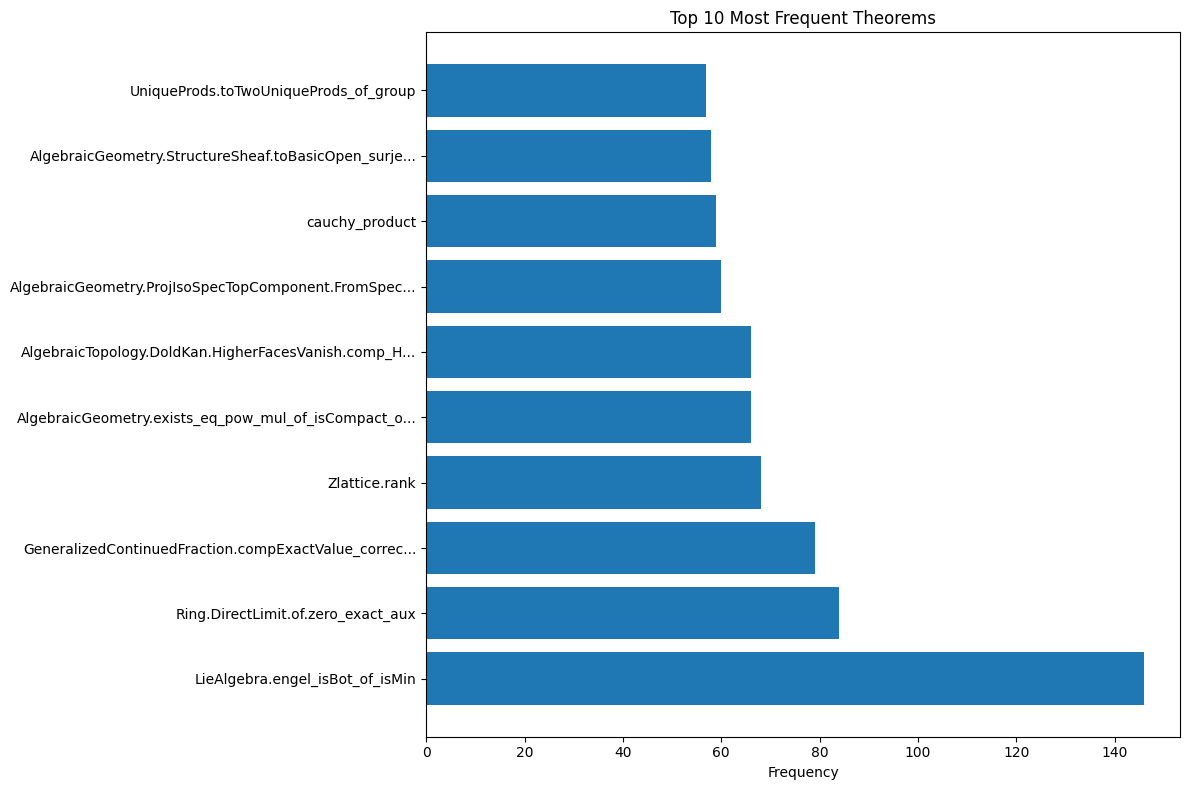

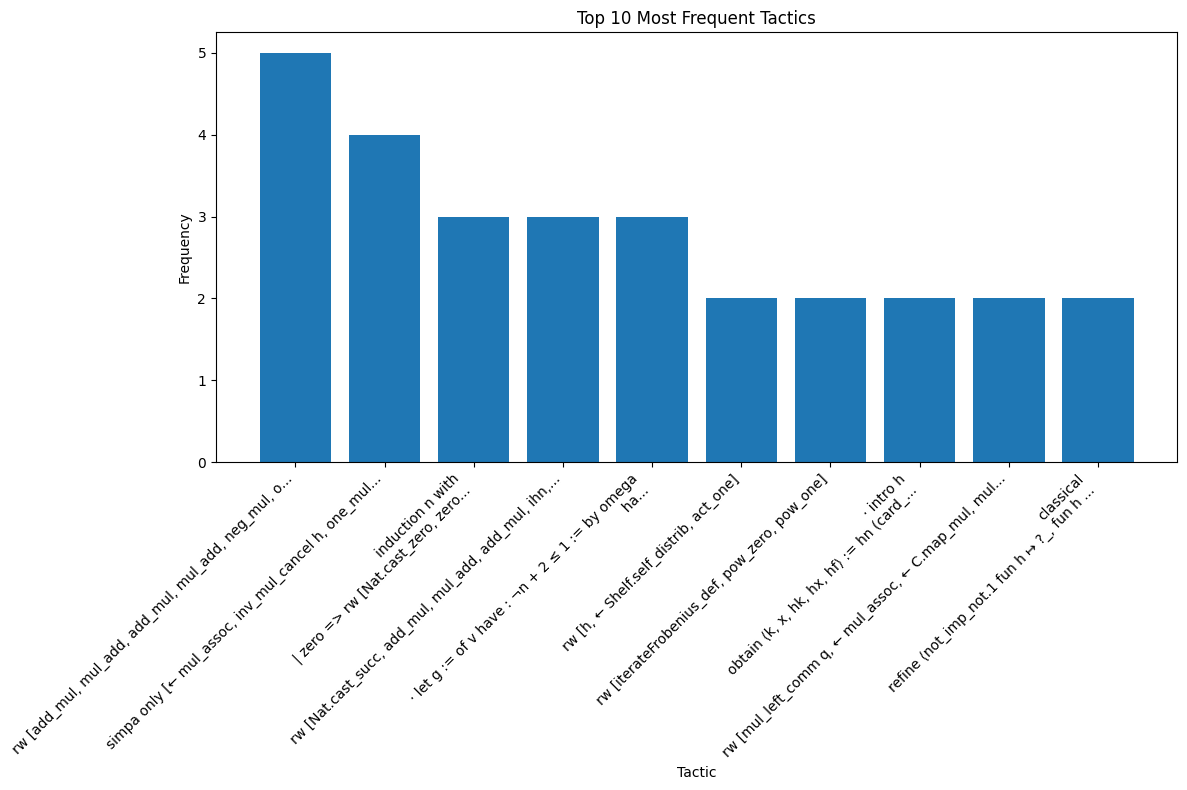

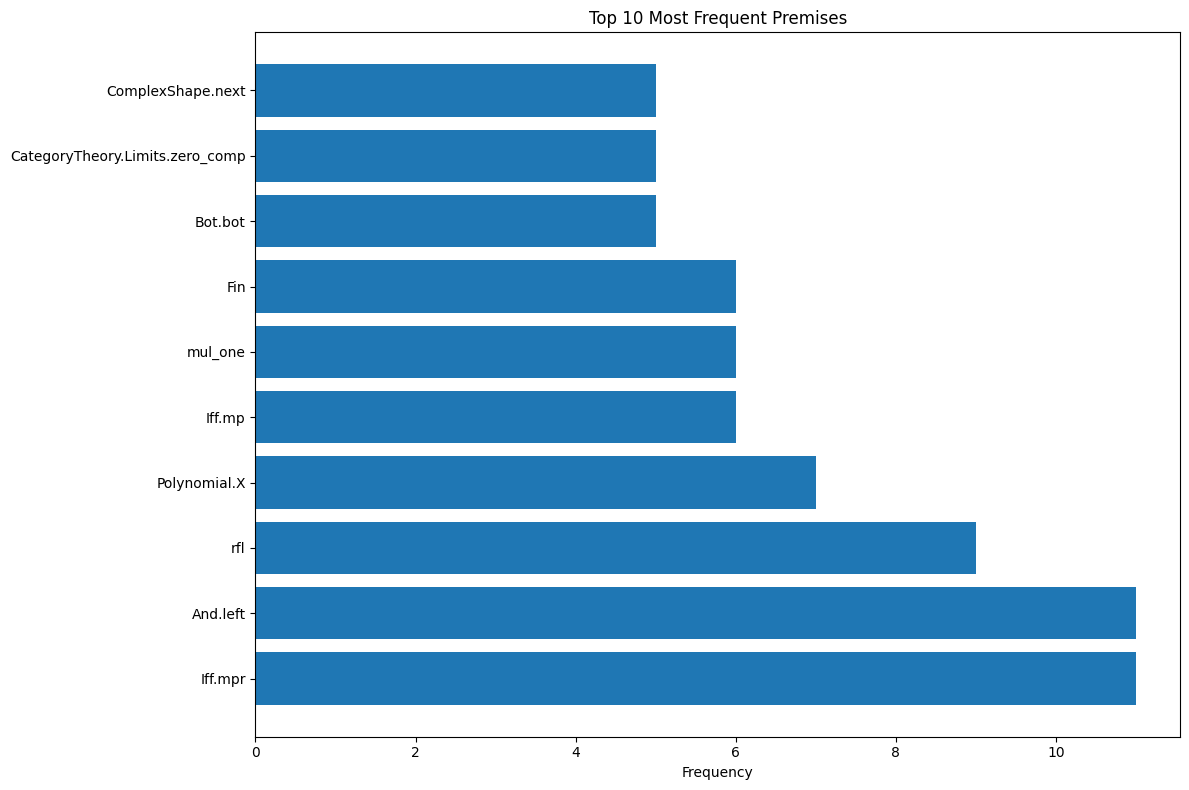

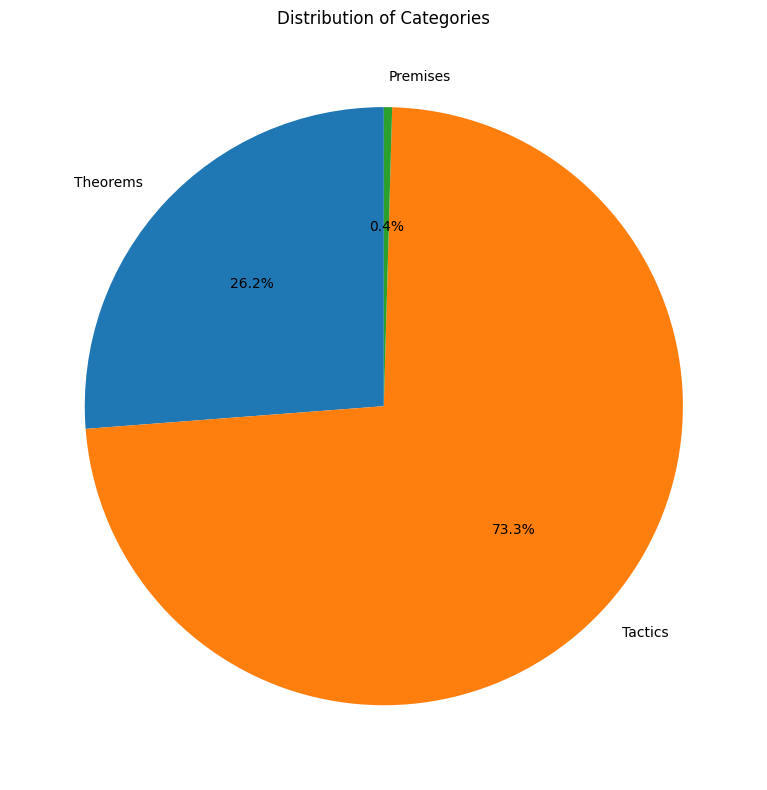


Summary Statistics:
Most frequent theorem: LieAlgebra.engel_isBot_of_isMin (146 occurrences)
Most frequent tactic: rw [add_mul, mul_add, add_mul, mul_add, neg_mul, one_mul] (5 occurrences)
Most frequent premise: Iff.mpr (11 occurrences)


In [66]:
# Analyze most frequent items in each category
print(f"Dataset statistics:")
print(f"Total theorems: {len(theorems)}")
print(f"Total tactics: {len(tactics)}")
print(f"Total premises: {len(premises)}")

# Count frequencies for each category
from collections import Counter
import matplotlib.pyplot as plt

# Count theorem frequencies (how often each theorem appears)
theorem_counts = Counter()
tactic_counts = Counter()
premise_counts = Counter()

# Count frequencies from already loaded data
for edge in edges:
    if edge[0].startswith("theorem_"):
        theorem = edge[0][8:]  # Remove "theorem_" prefix
        theorem_counts[theorem] += 1
    elif edge[0].startswith("tactic_"):
        tactic = edge[0][7:]  # Remove "tactic_" prefix
        tactic_counts[tactic] += 1
    
    if edge[1].startswith("premise_"):
        premise = edge[1][8:]  # Remove "premise_" prefix
        premise_counts[premise] += 1

# Plot 1: Top 10 theorems
plt.figure(figsize=(12, 8))
top_theorems = theorem_counts.most_common(10)
theorem_names = [t[0][:50] + "..." if len(t[0]) > 50 else t[0] for t in top_theorems]
theorem_counts_list = [t[1] for t in top_theorems]

plt.barh(theorem_names, theorem_counts_list)
plt.title('Top 10 Most Frequent Theorems')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# Plot 2: Top 10 tactics
plt.figure(figsize=(12, 8))
top_tactics = tactic_counts.most_common(10)
tactic_names = [t[0][:50] + "..." if len(t[0]) > 50 else t[0] for t in top_tactics]
tactic_counts_list = [t[1] for t in top_tactics]

plt.bar(range(len(tactic_names)), tactic_counts_list)
plt.title('Top 10 Most Frequent Tactics')
plt.xlabel('Tactic')
plt.ylabel('Frequency')
plt.xticks(range(len(tactic_names)), tactic_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 3: Top 10 premises
plt.figure(figsize=(12, 8))
top_premises = premise_counts.most_common(10)
premise_names = [p[0][:50] + "..." if len(p[0]) > 50 else p[0] for p in top_premises]
premise_counts_list = [p[1] for p in top_premises]

plt.barh(premise_names, premise_counts_list)
plt.title('Top 10 Most Frequent Premises')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# Plot 4: Distribution overview
plt.figure(figsize=(8, 8))
categories = ['Theorems', 'Tactics', 'Premises']
totals = [len(theorems), len(tactics), len(premises)]

plt.pie(totals, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Categories')
plt.tight_layout()
plt.show()

# Also print summary statistics
print(f"\nSummary Statistics:")
print(f"Most frequent theorem: {theorem_counts.most_common(1)[0][0]} ({theorem_counts.most_common(1)[0][1]} occurrences)")
print(f"Most frequent tactic: {tactic_counts.most_common(1)[0][0]} ({tactic_counts.most_common(1)[0][1]} occurrences)")
print(f"Most frequent premise: {premise_counts.most_common(1)[0][0]} ({premise_counts.most_common(1)[0][1]} occurrences)")


In [54]:
theorem_premises

[{'full_name': 'Bot.bot',
  'def_path': 'Mathlib/Order\\Notation.lean',
  'def_pos': [107, 3],
  'def_end_pos': [107, 6]}]

## Interact with Lean Programmatically

In [21]:
repo

LeanGitRepo(url='https://github.com/leanprover-community/mathlib4', commit='29dcec074de168ac2bf835a77ef68bbe069194c5')

### Interact through Tactics

In [2]:
from lean_dojo import *


In [3]:
theorem = Theorem(repo, "Mathlib/Algebra/BigOperators/Pi.lean", "pi_eq_sum_univ")

# For some theorems, it might take a few minutes.
dojo, state_0 = Dojo(theorem).__enter__()

In [4]:
state_0

TacticState(pp='ι : Type u_1\ninst✝² : Fintype ι\ninst✝¹ : DecidableEq ι\nR : Type u_2\ninst✝ : Semiring R\nx : ι → R\n⊢ x = ∑ i : ι, x i • fun j => if i = j then 1 else 0', id=0, message=None)

In [5]:
print(state_0.pp)

ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
x : ι → R
⊢ x = ∑ i : ι, x i • fun j => if i = j then 1 else 0


In [6]:
state_1 = dojo.run_tac(state_0, "revert x")

print(state_1.pp)

ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
⊢ ∀ (x : ι → R), x = ∑ i : ι, x i • fun j => if i = j then 1 else 0


In [7]:
state_2 = dojo.run_tac(state_0, "hello world!")

state_2

LeanError(error='<stdin>:1:1: unknown tactic')

In [8]:
dojo.run_tac(state_2, "skip")

RuntimeError: Attempting to run a tactic on an invalid state LeanError(error='<stdin>:1:1: unknown tactic').

In [9]:
dojo.run_tac(state_0, "sorry")

ProofGivenUp()

In [10]:
print(state_0.pp)

ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
x : ι → R
⊢ x = ∑ i : ι, x i • fun j => if i = j then 1 else 0


In [11]:
state_3 = dojo.run_tac(state_0, "ext")

print(state_3.pp)

case h
ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
x : ι → R
x✝ : ι
⊢ x x✝ = (∑ i : ι, x i • fun j => if i = j then 1 else 0) x✝


In [12]:
state_4 = dojo.run_tac(state_3, "simp")

print(state_4)

ProofFinished(tactic_state_id=3, message='')


In [31]:
dojo.is_successful

True

### Interact through Commands

In [13]:
entry = (repo, "Mathlib/Algebra/Module/Equiv.lean", 953)  # (repo, file_path, line_nb)
dojo, state_0 = Dojo(entry).__enter__()

In [14]:
state_0

CommandState(id=0, message=None)

In [15]:
dojo.run_cmd(state_0, "#eval 1")

CommandState(id=1, message='1')

In [16]:
dojo.run_cmd(state_0, "#eval x")

LeanError(error="unknown identifier 'x'")

In [17]:
state_1 = dojo.run_cmd(state_0, "def x := 1")

state_1

CommandState(id=3, message='')

In [18]:
dojo.run_cmd(state_1, "#eval x")

CommandState(id=4, message='1')

In [19]:
dojo.run_cmd(state_0, "#check addMonoidHomLequivNat")

CommandState(id=5, message='addMonoidHomLequivNat.{u_17, u_18, u_19} {A : Type u_17} {B : Type u_18} (R : Type u_19) [Semiring R] [AddCommMonoid A]\n[AddCommMonoid B] [Module R B] : (A →+ B) ≃ₗ[R] A →ₗ[ℕ] B')

In [20]:
dojo.run_cmd(state_0, "#check addMonoidEndRingEquivInt")

LeanError(error="unknown identifier 'addMonoidEndRingEquivInt'")